<h1 style="background-color:coral;
           font-family:New Times Roman;
           font-size:200%;
           color:black;
           text-align:center;
           border-radius:20px 20px;">
   <b>Choosing the Right Home EDA</b>
</h1>

### ***Hello, Kaggle community!***

  *In this notebook, I explore housing price data and test the hypothesis about whether there is a difference in prices between houses with up to 5 floors and houses with more than 5 floors. I conducted a detailed data analysis, created some interesting visualizations, built a dashboard, and tested the hypothesis, which might show a surprising result for some. If you like my work, feel free to support it by giving an "upvote." I’d also be happy to answer any questions in the comments, receive constructive feedback, and hear your suggestions! Since I'm just starting my journey in data analytics, your feedback is especially important to me for improving my projects.*


Here, you can take a closer look at the dataset. Prices are presented in rubles, and at the current exchange rate, 1$ ≈ 100₽.
https://www.kaggle.com/datasets/evgeniypolin/home-price

## **<font color='Coral'>Main purpose: conduct EDA and find out which of the signs have a big impact on pricing houses.</font>**

### *Tasks:*
#### *1. Perform data preprocessing;*
#### *2. Apply statistical methods to detect anomalies;*
#### *3. Identify patterns in the data;*
#### *4. Formulate a hypothesis about the data and conduct hypothesis testing;*
#### *5. Visualize the analysis results and create a dashboard.*


## **<font color='Goldenrod'>Data Overview</font>**  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from scipy.stats import *
from scipy import stats
from IPython.display import display, HTML
import missingno as msno
import statistics 
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)
df = pd.read_csv('/kaggle/input/home-price/home_price.csv')

In [2]:
#Explore the dataset, its anomalies and missing values.
print(df.info(), end = '\n' * 2)
print('The percentage of missing values in the columns before any manipulations.:')
for col in df.columns:
  pct_missing = np.mean(df[col].isnull())
  print('{} - {}%'.format(col, round(pct_missing*100)))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   last_price           23699 non-null  float64
 1   total_area           23699 non-null  float64
 2   rooms                23699 non-null  int64  
 3   ceiling_height       14504 non-null  float64
 4   floors_total         23613 non-null  float64
 5   living_area          21796 non-null  float64
 6   floor                23699 non-null  int64  
 7   is_apartment         2775 non-null   object 
 8   studio               23699 non-null  bool   
 9   open_plan            23699 non-null  bool   
 10  kitchen_area         21421 non-null  float64
 11  balcony              12180 non-null  float64
 12  airports_nearest     18157 non-null  float64
 13  cityCenters_nearest  18180 non-null  float64
 14  parks_around3000     18181 non-null  float64
 15  parks_nearest        8079 non-null  

In [3]:
df.sample(7)

,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest
21100,3100000.0,32.0,1,2.5,5.0,18.0,2,NaN,False,False,6.0,1.0,44087.0,13975.0,0.0,NaN,0.0,NaN
21719,5690000.0,60.0,3,2.5,12.0,43.0,2,NaN,False,False,6.0,NaN,51464.0,14756.0,0.0,NaN,1.0,917.0
18791,4990000.0,52.9,1,2.8,12.0,16.3,12,NaN,False,False,13.4,2.0,34530.0,14398.0,0.0,NaN,1.0,965.0
5678,8500000.0,72.0,2,3.0,6.0,25.0,5,NaN,False,False,35.0,NaN,25551.0,4399.0,0.0,NaN,1.0,530.0
13100,2140000.0,64.0,3,2.7,9.0,45.0,7,NaN,False,False,7.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
17166,3750000.0,41.0,1,2.7,16.0,17.1,6,NaN,False,False,10.3,0.0,NaN,NaN,NaN,NaN,NaN,NaN
20602,5200000.0,59.7,3,2.6,9.0,35.0,6,NaN,False,False,7.0,2.0,12407.0,14998.0,0.0,NaN,1.0,1016.0


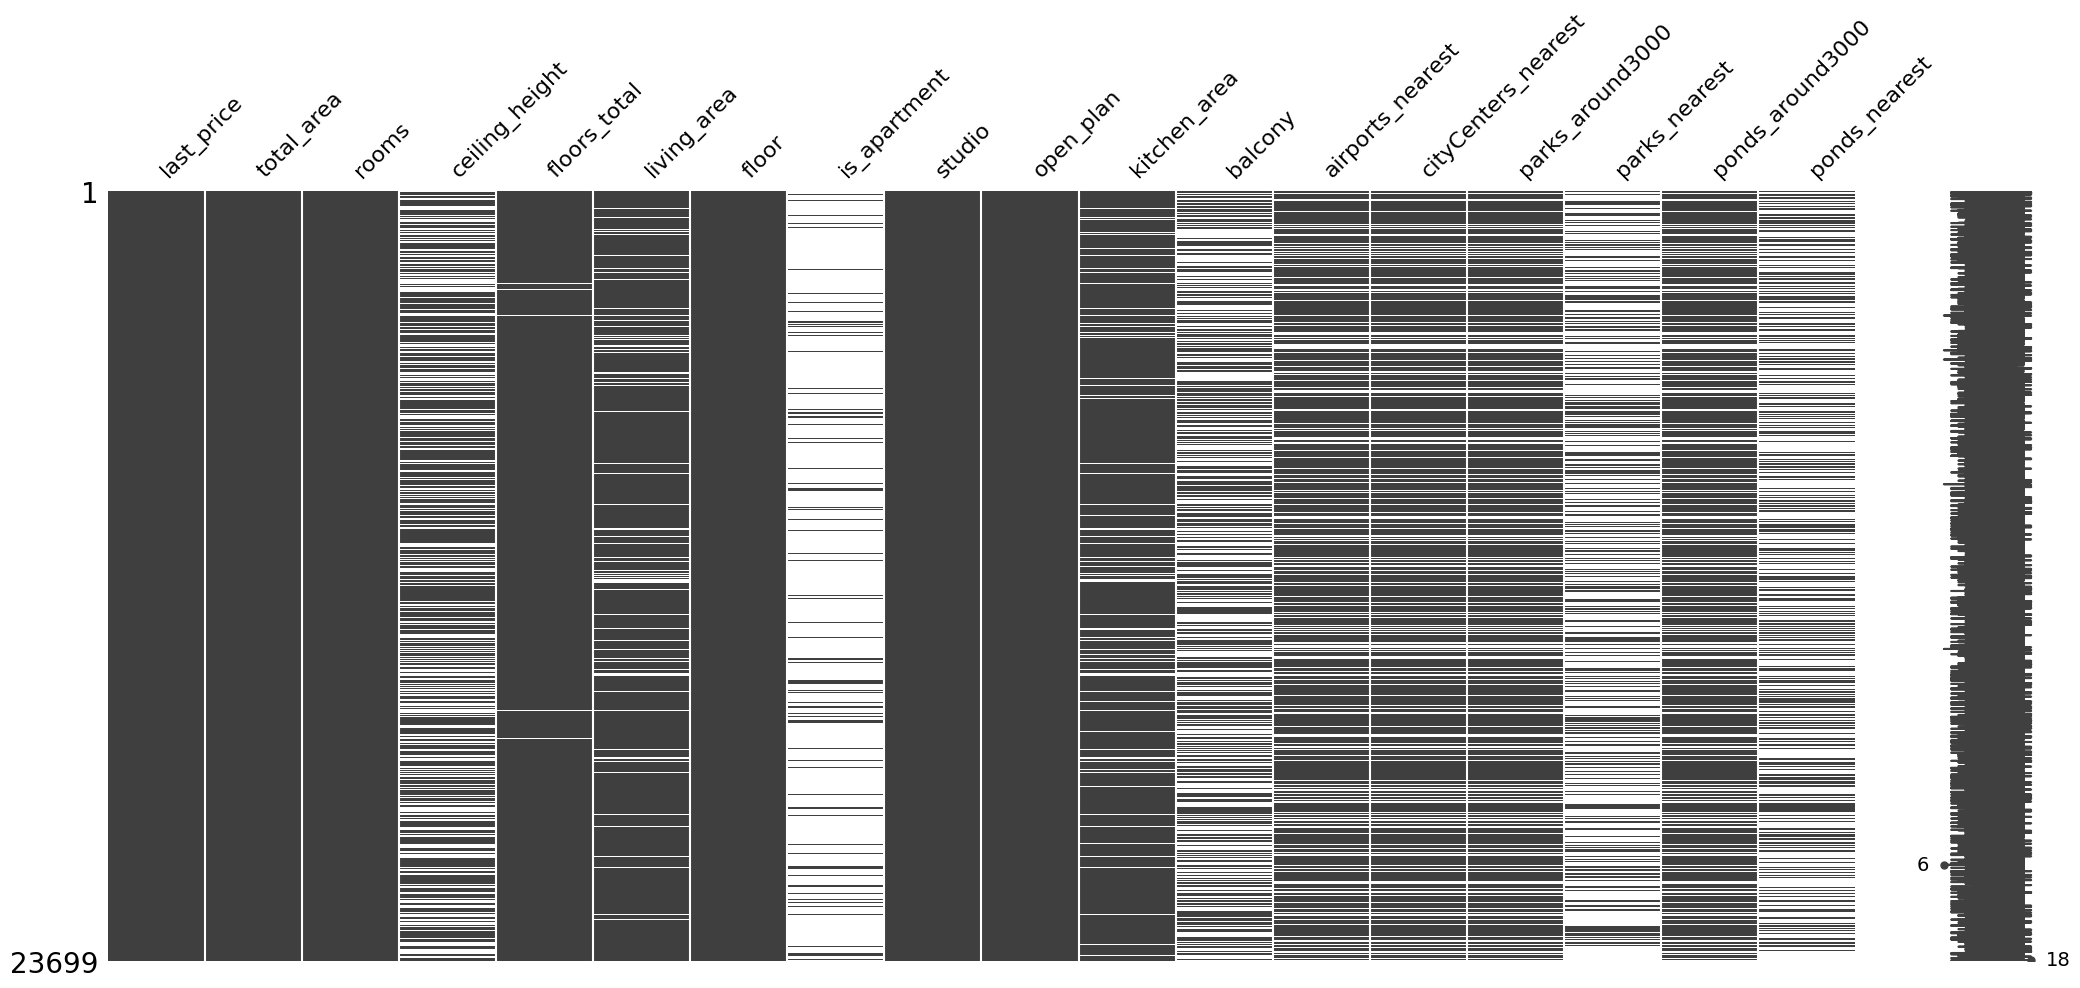

In [4]:
#A missing values matrix is suitable for determining whether there is any pattern in the missing data. 

msno.matrix(df)
plt.savefig("Missing values matrix.png")
plt.show()

#### <font color='Teal'>Missing values appear random; a pattern would be if missing values occurred only in the first half of observations.</font>

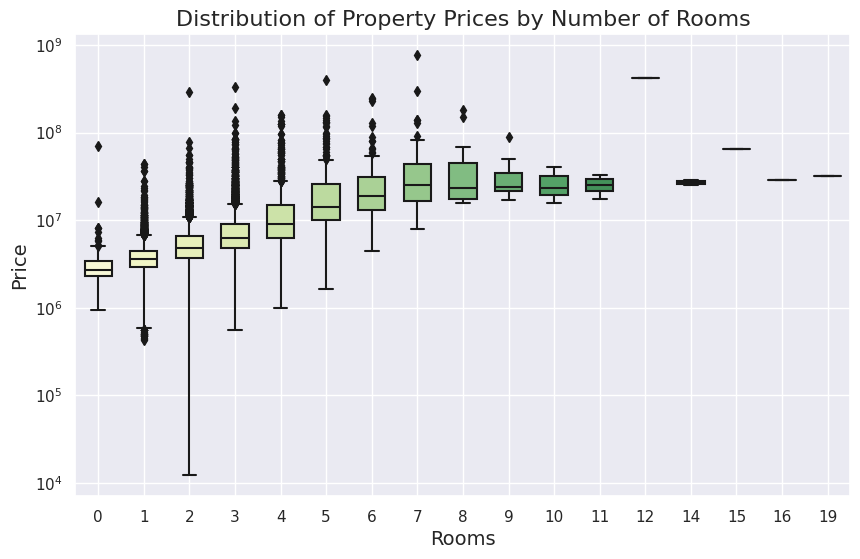

In [5]:
sb.set_theme(style="darkgrid")
plt.figure(figsize=(10, 6))
sb.boxplot(x="rooms", y="last_price", data=df, palette="YlGn", width=0.6)
plt.yscale('log')
plt.title("Distribution of Property Prices by Number of Rooms", fontsize=16)
plt.xlabel("Rooms", fontsize=14)  
plt.ylabel("Price", fontsize=14)
plt.grid(True) 
plt.show()

#### <font color='Teal'>Examining median, standard deviation, max, and min values helps detect anomalies.</font>

 ## **<font color='Goldenrod'>Anomalies & Missing Data</font>** 

In [6]:
#Due to significant data loss and low informativeness of this column, the decision has been made to remove it.
df.drop('is_apartment', axis = 1, inplace = True)

In [7]:
print(f'The number of duplicates in the given dataset = {df.duplicated().sum()}')

The number of duplicates in the given dataset = 1


In [8]:
df = df.drop_duplicates()

#### <font color='Teal'>To shorten the code, I'll use loops to check and remove anomalies by comparing max values before and after cleaning.</font>

In [9]:
main_columns = ['last_price', 'total_area', 'rooms', 'floors_total', 'living_area', 'kitchen_area']

for column in main_columns:
  before = df[column].value_counts().sort_index(ascending=False)
  print(f'Maximum values before removing outliers in the column: {before.head(5)}', end = '\n\n')

Maximum values before removing outliers in the column: last_price
763000000.0    1
420000000.0    1
401300000.0    1
330000000.0    1
300000000.0    1
Name: count, dtype: int64

Maximum values before removing outliers in the column: total_area
900.0    1
631.2    1
631.0    1
618.0    1
590.0    1
Name: count, dtype: int64

Maximum values before removing outliers in the column: rooms
19    1
16    1
15    1
14    2
12    1
Name: count, dtype: int64

Maximum values before removing outliers in the column: floors_total
60.0     1
52.0     1
37.0     1
36.0     3
35.0    24
Name: count, dtype: int64

Maximum values before removing outliers in the column: living_area
409.7    1
409.0    1
347.5    1
332.0    1
322.3    1
Name: count, dtype: int64

Maximum values before removing outliers in the column: kitchen_area
112.0    1
107.0    1
100.7    1
100.0    1
93.2     1
Name: count, dtype: int64



#### <font color='Teal'>Removing rows where values deviate beyond ±3 standard deviations from the mean.</font>

In [10]:
for column in main_columns:
  mean = df[column].mean()
  std = df[column].std()
  threshold = 3
  df = df[(df[column] < mean + threshold * std) & (df[column] > mean - threshold * std)]

In [11]:
for column in main_columns:
  after = df[column].value_counts().sort_index(ascending=False)
  print(f'Maximum values in the column after removing outliers: {after.head(5)}', end = '\n\n')

Maximum values in the column after removing outliers: last_price
39000000.0    1
37272000.0    1
37000000.0    2
36000000.0    3
35107000.0    1
Name: count, dtype: int64

Maximum values in the column after removing outliers: total_area
147.7    1
145.0    3
141.0    1
139.2    1
139.0    1
Name: count, dtype: int64

Maximum values in the column after removing outliers: rooms
4     736
3    4915
2    6908
1    7032
Name: count, dtype: int64

Maximum values in the column after removing outliers: floors_total
29.0      1
28.0     20
27.0    146
26.0    107
25.0    880
Name: count, dtype: int64

Maximum values in the column after removing outliers: living_area
75.50    2
75.40    1
75.25    1
75.20    4
75.10    2
Name: count, dtype: int64

Maximum values in the column after removing outliers: kitchen_area
24.10     1
24.03     1
24.00    23
23.90     2
23.80     4
Name: count, dtype: int64



In [12]:
# We calculate the mean, median, and mode after cleaning anomalies to understand the preferred method for filling missing values.
for column in df:
  print(f'In {[column]}:Mean - {df[column].mean().round()}, Median - {df[column].median()}, Mode - {statistics.mode(df[column])}')

In ['last_price']:Mean - 5294905.0, Median - 4500000.0, Mode - 4500000.0
In ['total_area']:Mean - 55.0, Median - 50.2, Mode - 45.0
In ['rooms']:Mean - 2.0, Median - 2.0, Mode - 1
In ['ceiling_height']:Mean - 3.0, Median - 2.6, Mode - 2.5
In ['floors_total']:Mean - 11.0, Median - 9.0, Mode - 5.0
In ['living_area']:Mean - 31.0, Median - 30.0, Mode - 18.0
In ['floor']:Mean - 6.0, Median - 4.0, Mode - 2
In ['studio']:Mean - 0.0, Median - 0.0, Mode - False
In ['open_plan']:Mean - 0.0, Median - 0.0, Mode - False
In ['kitchen_area']:Mean - 10.0, Median - 9.0, Mode - 6.0
In ['balcony']:Mean - 1.0, Median - 1.0, Mode - 1.0
In ['airports_nearest']:Mean - 28905.0, Median - 27102.0, Mode - 37434.0
In ['cityCenters_nearest']:Mean - 14718.0, Median - 13369.0, Mode - 8460.0
In ['parks_around3000']:Mean - 1.0, Median - 0.0, Mode - 0.0
In ['parks_nearest']:Mean - 492.0, Median - 458.0, Mode - 441.0
In ['ponds_around3000']:Mean - 1.0, Median - 0.0, Mode - 0.0
In ['ponds_nearest']:Mean - 529.0, Median - 

#### <font color='Teal'>Filling missing values with the most appropriate values based on my judgment.</font>

In [13]:
df.fillna({'ceiling_height': df['ceiling_height'].median(),
  'floors_total': statistics.mode(df['floors_total']),
  'balcony': statistics.mode(df['balcony']),
  'airports_nearest' : df['airports_nearest'].mean(),
  'cityCenters_nearest': df['cityCenters_nearest'].mean(),
  'parks_around3000': 1,
  'parks_nearest' : df['parks_nearest'].mean(),
  'ponds_around3000': 1,
  'ponds_nearest' : df['ponds_nearest'].mean()},
inplace=True)

#### <font color='Teal'>I handle anomalies in the "balcony" column after filling missing values to minimize data loss.</font>

In [14]:
mean = df['balcony'].mean()
std = df['balcony'].std()
threshold = 3
df = df[(df['balcony'] < mean + threshold * std) & (df['balcony'] > mean - threshold * std)]


print(f'Checking the remaining values and their quantities in the column:\n{df.balcony.value_counts().sort_values()}')

Checking the remaining values and their quantities in the column:
balcony
3.0       59
0.0     3119
2.0     3224
1.0    12787
Name: count, dtype: int64


In [15]:
df = df.reset_index()
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19189 entries, 0 to 19188
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   index                19189 non-null  int64  
 1   last_price           19189 non-null  float64
 2   total_area           19189 non-null  float64
 3   rooms                19189 non-null  int64  
 4   ceiling_height       19189 non-null  float64
 5   floors_total         19189 non-null  float64
 6   living_area          19189 non-null  float64
 7   floor                19189 non-null  int64  
 8   studio               19189 non-null  bool   
 9   open_plan            19189 non-null  bool   
 10  kitchen_area         19189 non-null  float64
 11  balcony              19189 non-null  float64
 12  airports_nearest     19189 non-null  float64
 13  cityCenters_nearest  19189 non-null  float64
 14  parks_around3000     19189 non-null  float64
 15  parks_nearest        19189 non-null 

In [16]:
rest = 19189 / 23699 * 100
print(f"After cleaning the dataset, {round(rest,2)}% of the data remains.", end = '\n\n')

After cleaning the dataset, 80.97% of the data remains.



#### <font color='Teal'>After preliminary data processing, less than 20% of the data was lost</font>

## **<font color='Goldenrod'>Statistical Analysis</font>**

In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
index,19189.0,1.183969e+04,6.843606e+03,1.0,5.916000e+03,1.183800e+04,1.776500e+04,23698.0
last_price,19189.0,5.250137e+06,3.213100e+06,430000.0,3.400000e+06,4.500000e+06,6.200000e+06,39000000.0
total_area,19189.0,5.426714e+01,1.932940e+01,14.0,3.960000e+01,5.000000e+01,6.500000e+01,147.7
rooms,19189.0,1.954349e+00,8.693592e-01,1.0,1.000000e+00,2.000000e+00,3.000000e+00,4.0
ceiling_height,19189.0,2.678669e+00,6.950019e-01,1.0,2.600000e+00,2.600000e+00,2.700000e+00,32.0
floors_total,19189.0,1.061051e+01,6.477068e+00,1.0,5.000000e+00,9.000000e+00,1.500000e+01,29.0
living_area,19189.0,3.100870e+01,1.333736e+01,2.0,1.820000e+01,2.970000e+01,4.000000e+01,75.5
floor,19189.0,5.821408e+00,4.792119e+00,1.0,2.000000e+00,4.000000e+00,8.000000e+00,27.0
kitchen_area,19189.0,9.555653e+00,3.424285e+00,1.3,7.000000e+00,9.000000e+00,1.100000e+01,24.1
balcony,19189.0,1.011621e+00,5.854361e-01,0.0,1.000000e+00,1.000000e+00,1.000000e+00,3.0


Text(0, 0.5, 'Last Price')

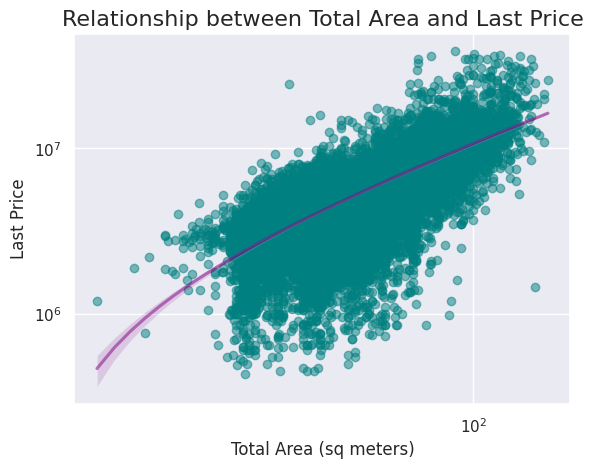

In [18]:
sb.regplot(x=df['total_area'], y=df['last_price'], scatter_kws={'alpha':0.5, 'color':'teal'}, line_kws={'alpha':0.5, 'color':'purple'})
plt.xscale('log') 
plt.yscale('log') 
plt.title('Relationship between Total Area and Last Price', fontsize=16)
plt.xlabel('Total Area (sq meters)', fontsize=12)
plt.ylabel('Last Price', fontsize=12)

In [19]:
print(f'The minimum housing price is {df.last_price.min()}₽, while the maximum is {df.last_price.max()}₽. The average price is {df.last_price.mean().round()}₽. The most frequent price listed in the ads is {statistics.mode(df.last_price)}₽', end='\n\n')
print(f'The standard deviation for the apartment area is {df.total_area.std().round(2)} m²', end='\n\n')
print(f'The most distant housing from the airport is located almost {round(df.airports_nearest.max() / 1000)} km away from the airport, while the average distance is about {round(df.airports_nearest.mean() / 1000)} km', end='\n\n')

The minimum housing price is 430000.0₽, while the maximum is 39000000.0₽. The average price is 5250137.0₽. The most frequent price listed in the ads is 4500000.0₽

The standard deviation for the apartment area is 19.33 m²

The most distant housing from the airport is located almost 85 km away from the airport, while the average distance is about 29 km



## **<font color='Goldenrod'>Pattern Search</font>**

#### <font color='Teal'>The code groups data by total floors and number of rooms, then applies various statistical functions to other columns.</font>

In [20]:
#This code block outputs the average values of living area, price, and ceiling height for each number of floors.
grouped_by_floor = df.groupby('floors_total').agg({'living_area':'mean', 'last_price':'mean', 'ceiling_height':'mean'})
print(grouped_by_floor.round(2), end='\n' * 2)

#This code outputs the maximum values of living area and price for each number of rooms.
grouped_by_rooms = df.groupby('rooms').agg({'living_area':'max', 'last_price':'max'})
print(grouped_by_rooms.round(2))

              living_area  last_price  ceiling_height
floors_total                                         
1.0                 34.00  2915000.00            2.68
2.0                 30.83  2600363.08            2.84
3.0                 33.20  4539607.84            2.80
4.0                 36.42  5835100.64            2.84
5.0                 31.84  4186113.20            2.67
6.0                 37.88  7179694.18            2.86
7.0                 36.75  7777688.22            2.77
8.0                 34.22  8659353.61            2.71
9.0                 31.21  4657711.19            2.60
10.0                30.78  5848556.29            2.65
11.0                31.84  7345390.36            2.68
12.0                30.22  5467868.89            2.62
13.0                28.55  6868212.34            2.65
14.0                28.22  5512194.41            2.69
15.0                30.56  6113575.64            2.67
16.0                29.33  6021161.28            2.68
17.0                27.62  5

## **<font color='Goldenrod'>Data Visualization</font>**

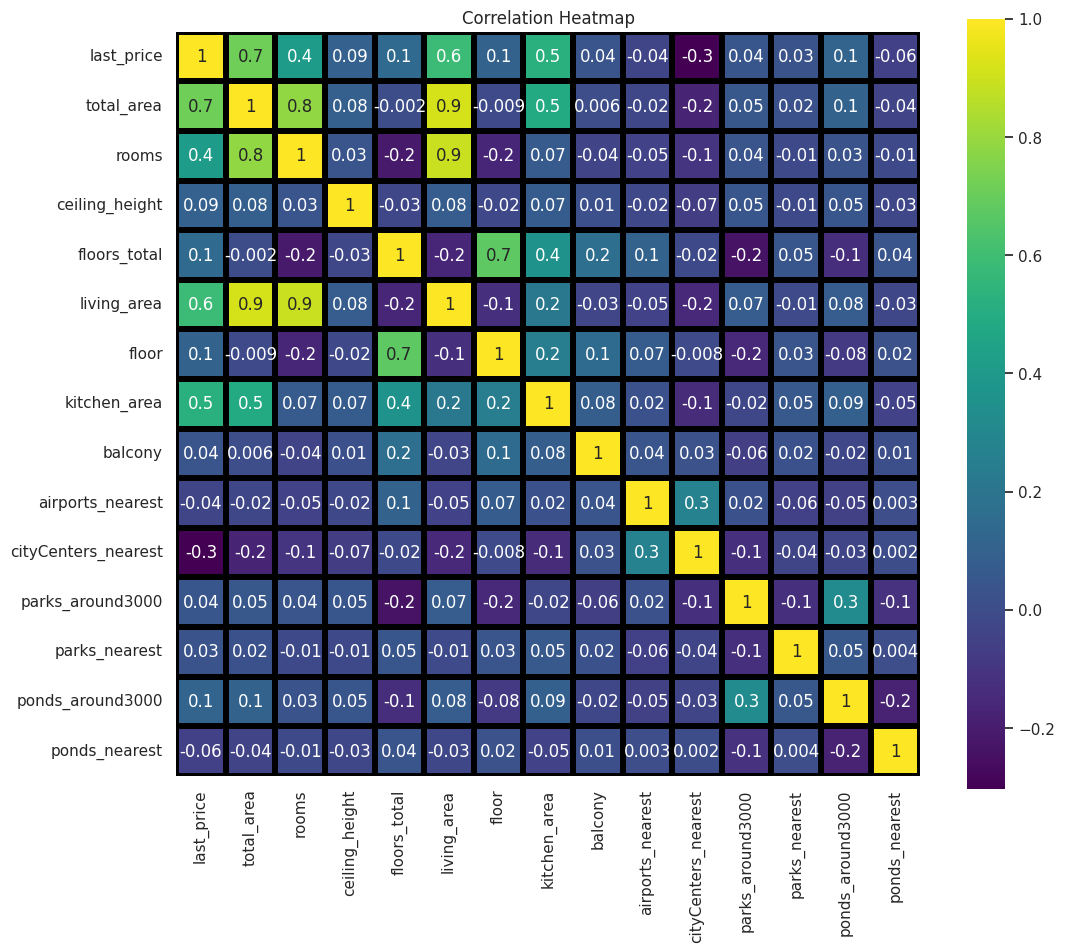

In [21]:
#Heatmap
columns_for_cor = ['last_price', 'total_area', 'rooms', 'ceiling_height', 'floors_total', 'living_area', 'floor', 'kitchen_area', 'balcony', 'airports_nearest', 'cityCenters_nearest', 'parks_around3000', 'parks_nearest', 'ponds_around3000', 'ponds_nearest']
corr = df[columns_for_cor].corr()
plt.figure(figsize=(12,10))
sb.heatmap(corr, annot=True, fmt='.1g', cmap= 'viridis', linewidths=3, linecolor='black', square=True)
plt.title('Correlation Heatmap')
plt.savefig("Heatmap")
plt.show()

#### <font color='Teal'>The heatmap shows strong correlations between last_price and total_area, rooms and living_area, etc. Reminder: correlation doesn't imply causation.</font>

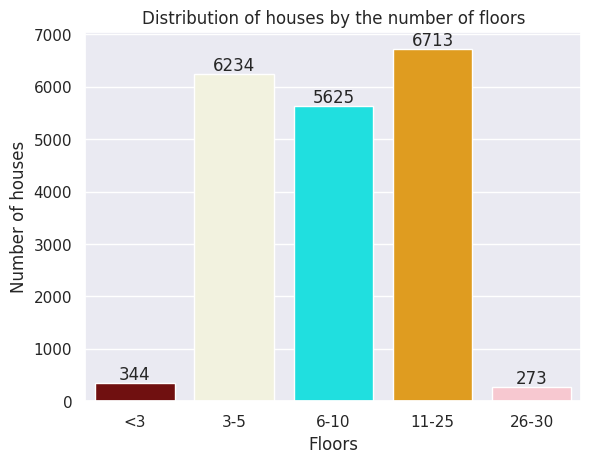

In [22]:
#This code groups houses by ranges of the number of floors.
bins = [0,2,5,10,25,30]
labels = ['<3','3-5','6-10','11-25','26-30']

#Barplot
df['floors_total_group'] = pd.cut(df['floors_total'], bins=bins, labels=labels, right=True)
floors_group_size = df['floors_total_group'].value_counts().sort_index()
ax = sb.barplot(x = floors_group_size.index, y=floors_group_size.values, palette={'<3':'maroon','3-5':'beige','6-10':'aqua','11-25':'orange','26-30':'pink'})
for i in range(len(floors_group_size)):
  ax.annotate(str(floors_group_size.values[i]),xy=(i,floors_group_size.values[i]),ha='center',va='bottom')
plt.xlabel('Floors')
plt.ylabel('Number of houses')
plt.title('Distribution of houses by the number of floors')
plt.savefig('floors_group_size')
plt.show()

## **<font color='Goldenrod'>Hypothesis Testing</font>**
### <font color='Teal'>H0: Apartments in buildings with ≤ 5 floors are cheaper than apartments in buildings with > 5 floors</font>
### <font color='Teal'>H1: There is no difference in the price of apartments in buildings of different sizes</font>



---

> **Note:** The null hypothesis (H₀) in this analysis is intentionally formulated in a reverse way compared to the standard approach. This was done for educational purposes to explore how statistical testing behaves when H₀ assumes an effect or difference, rather than no effect. Please keep in mind that the interpretation of the p-value is flipped accordingly: a low p-value here suggests evidence *against* the idea that smaller buildings are cheaper, and *in favor* of the alternative — that there is no significant price difference based on building size.

---


#### <font color='Teal'>We first check for normality with the Anderson-Darling test, then choose and conduct the appropriate hypothesis test.</font>

In [23]:
group1 = df[df['floors_total'] <= 5]['last_price']
group2 = df[df['floors_total'] > 5]['last_price']

anderson_before5 = anderson(group1)
anderson_after5 = anderson(group2)

print(f'Anderson-Darling test for buildings with up to 5 floors (inclusive):\nStatistic: {anderson_before5.statistic.round(3)}\nCritical value: {anderson_before5.critical_values}', end = '\n' * 2)
print(f'Anderson-Darling test for buildings with more than 5 floors:\nStatistic: {anderson_after5.statistic.round(3)}\nCritical value: {anderson_after5.critical_values}', end = '\n' * 2)


Anderson-Darling test for buildings with up to 5 floors (inclusive):
Statistic: 282.021
Critical value: [0.576 0.656 0.787 0.917 1.091]

Anderson-Darling test for buildings with more than 5 floors:
Statistic: 746.938
Critical value: [0.576 0.656 0.787 0.918 1.092]



In [24]:
if anderson_before5.statistic > anderson_before5.critical_values[4]:
  print(f'Since the test statistic {anderson_before5.statistic.round(3)} exceeds the critical value at each significance level {anderson_before5.critical_values[0:5]}, the data for the group of buildings with fewer than 5 floors is not normally distributed', end = '\n' * 2)

if anderson_before5.statistic <= anderson_before5.critical_values[2]:
  print(f'Since the test statistic {anderson_before5.statistic.round(3)} does not exceed the critical value {anderson_before5.critical_values[2]}, the data for the group of buildings with fewer than 5 floors is normally distributed', end = '\n' * 2)

if anderson_after5.statistic > anderson_after5.critical_values[4]:
  print(f'Since the test statistic {anderson_after5.statistic.round(3)} exceeds the critical value at each significance level {anderson_after5.critical_values[0:5]}, the data for the group of buildings with more than 5 floors is not normally distributed', end = '\n' * 2)

if anderson_after5.statistic <= anderson_after5.critical_values[2]:
  print(f'Since the test statistic {anderson_after5.statistic.round(3)} does not exceed the critical value {anderson_after5.critical_values[2]}, the data for the group of buildings with more than 5 floors is normally distributed', end = '\n' * 2)


Since the test statistic 282.021 exceeds the critical value at each significance level [0.576 0.656 0.787 0.917 1.091], the data for the group of buildings with fewer than 5 floors is not normally distributed

Since the test statistic 746.938 exceeds the critical value at each significance level [0.576 0.656 0.787 0.918 1.092], the data for the group of buildings with more than 5 floors is not normally distributed



#### <font color='Teal'>The Mann-Whitney U test is used when the t-test's normality assumption is violated.</font>

In [25]:
u_stat, p_value = mannwhitneyu(group1, group2)
print(f'Mann-Whitney test results: \nStatistic: {u_stat}\nP-value: {p_value}', end = '\n\n')

if p_value < 0.05:
  print('The null hypothesis is accepted: there are statistically significant differences in prices between buildings with up to 5 floors (inclusive) and buildings with more than 5 floors.')

if p_value >= 0.05:
  print('The null hypothesis is rejected, and the alternative is accepted: there is no statistically significant difference in apartment prices between buildings with different numbers of floors.')



Mann-Whitney test results: 
Statistic: 26378990.5
P-value: 0.0

The null hypothesis is accepted: there are statistically significant differences in prices between buildings with up to 5 floors (inclusive) and buildings with more than 5 floors.


## **<font color='Goldenrod'>Dashboard</font>**
#### <font color='Teal'>The fact that apartments are indeed cheaper is well depicted in the dashboard.</font>

https://datalens.yandex/qo9uqolmjevid

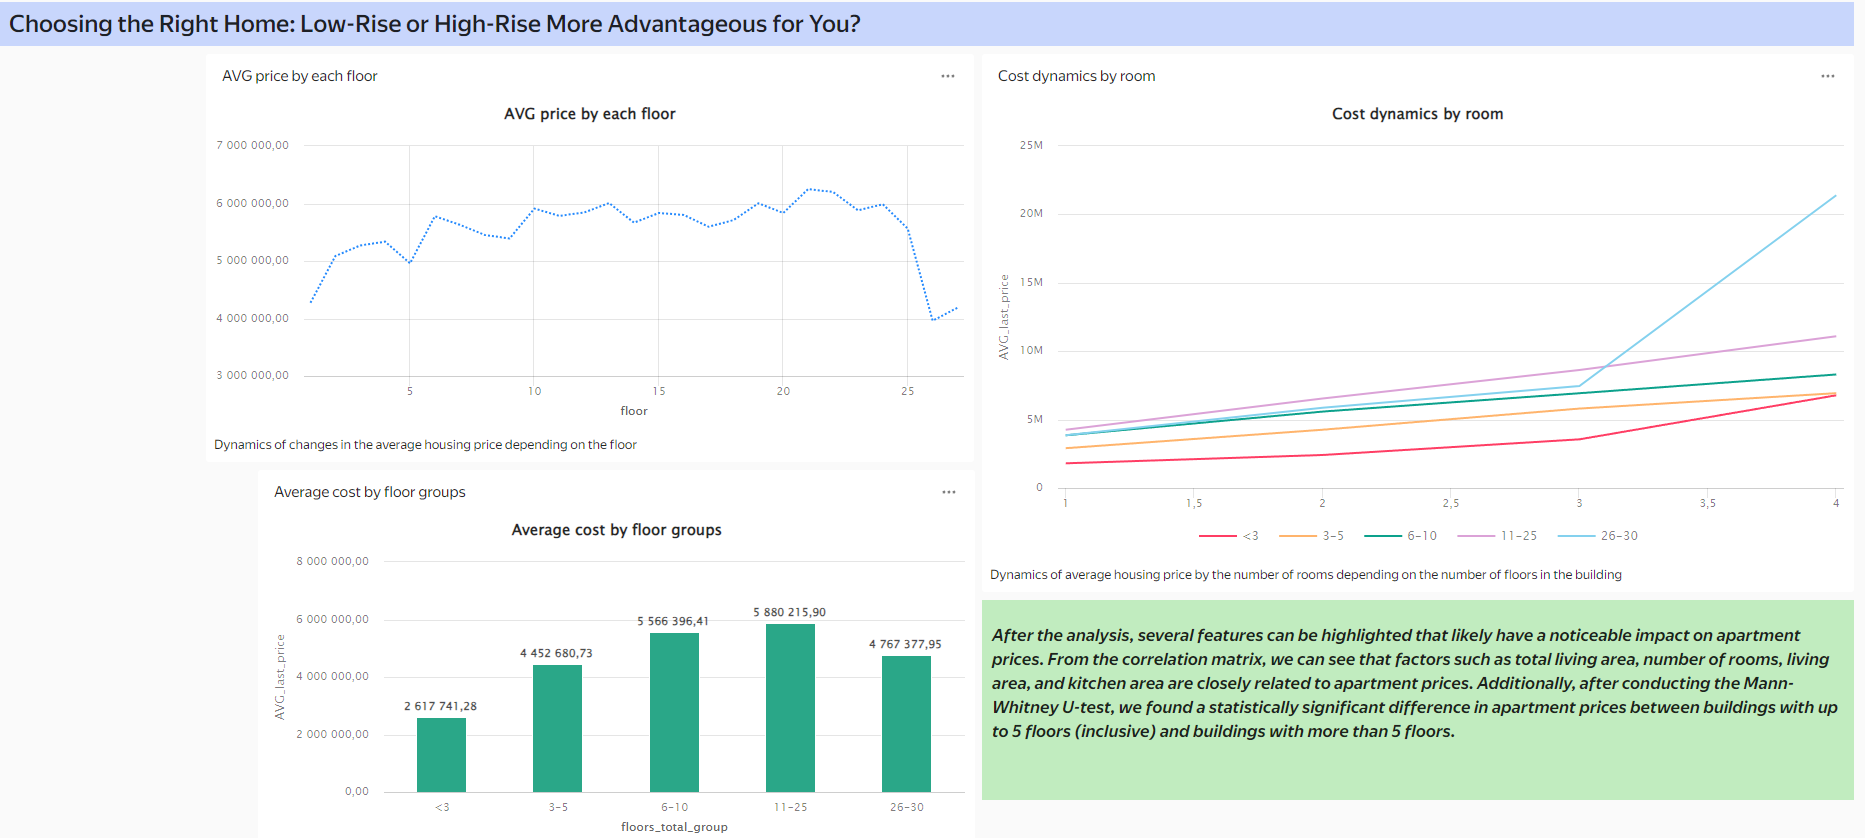